In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"marthalabhargavi","key":"34131e03eefe3399e243c8062036e6d5"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d abdulhasibuddin/plant-doc-dataset

Dataset URL: https://www.kaggle.com/datasets/abdulhasibuddin/plant-doc-dataset
License(s): unknown
100% 880M/882M [00:10<00:00, 45.1MB/s]
100% 882M/882M [00:10<00:00, 85.7MB/s]


In [ ]:
!unzip plant-doc-dataset.zip

Archive:  plant-doc-dataset.zip
  inflating: PlantDoc-Dataset/test/Apple Scab Leaf/Apple Scab Leaf (1).jpg  
  inflating: PlantDoc-Dataset/test/Apple Scab Leaf/Apple Scab Leaf (10).jpg  
  inflating: PlantDoc-Dataset/test/Apple Scab Leaf/Apple Scab Leaf (2).jpg  
  inflating: PlantDoc-Dataset/test/Apple Scab Leaf/Apple Scab Leaf (3).jpg  
  inflating: PlantDoc-Dataset/test/Apple Scab Leaf/Apple Scab Leaf (4).jpg  
  inflating: PlantDoc-Dataset/test/Apple Scab Leaf/Apple Scab Leaf (5).jpg  
  inflating: PlantDoc-Dataset/test/Apple Scab Leaf/Apple Scab Leaf (6).jpg  
  inflating: PlantDoc-Dataset/test/Apple Scab Leaf/Apple Scab Leaf (7).jpg  
  inflating: PlantDoc-Dataset/test/Apple Scab Leaf/Apple Scab Leaf (8).jpg  
  inflating: PlantDoc-Dataset/test/Apple Scab Leaf/Apple Scab Leaf (9).jpg  
  inflating: PlantDoc-Dataset/test/Apple leaf/Apple leaf (1).jpg  
  inflating: PlantDoc-Dataset/test/Apple leaf/Apple leaf (2).jpg  
  inflating: PlantDoc-Dataset/test/Apple leaf/Apple leaf (3).jp

In [ ]:
import os

for root, dirs, files in os.walk("data", topdown=True):
    print(root, len(files))


In [ ]:
base_dir = "/content/PlantDoc-Dataset/train"

In [ ]:
import os

classes = os.listdir(base_dir)

plants = set()

for c in classes:
    plant = c.split(" ")[0]   # plant name
    plants.add(plant)

print("Plants present in dataset:")
print(plants)

Plants present in dataset:
{'Potato', 'Corn', 'Cherry', 'Squash', 'Blueberry', 'Strawberry', 'Bell_pepper', 'Peach', 'Tomato', 'Raspberry', 'grape', 'Apple', 'Soyabean'}


In [ ]:
plant_dict = {}

for c in classes:
    plant = c.split("_")[0]

    if plant not in plant_dict:
        plant_dict[plant] = []

    plant_dict[plant].append(c)

for plant in plant_dict:
    print("\nPlant:", plant)
    for disease in plant_dict[plant]:
        print("  ", disease)


Plant: Tomato Early blight leaf
   Tomato Early blight leaf

Plant: grape leaf
   grape leaf

Plant: Tomato Septoria leaf spot
   Tomato Septoria leaf spot

Plant: Corn Gray leaf spot
   Corn Gray leaf spot

Plant: Tomato mold leaf
   Tomato mold leaf

Plant: Corn leaf blight
   Corn leaf blight

Plant: Apple rust leaf
   Apple rust leaf

Plant: Strawberry leaf
   Strawberry leaf

Plant: Tomato leaf yellow virus
   Tomato leaf yellow virus

Plant: Cherry leaf
   Cherry leaf

Plant: Blueberry leaf
   Blueberry leaf

Plant: Raspberry leaf
   Raspberry leaf

Plant: Tomato leaf mosaic virus
   Tomato leaf mosaic virus

Plant: Apple Scab Leaf
   Apple Scab Leaf

Plant: Tomato leaf
   Tomato leaf

Plant: Corn rust leaf
   Corn rust leaf

Plant: Tomato leaf bacterial spot
   Tomato leaf bacterial spot

Plant: Bell
   Bell_pepper leaf spot
   Bell_pepper leaf

Plant: Apple leaf
   Apple leaf

Plant: Potato leaf late blight
   Potato leaf late blight

Plant: grape leaf black rot
   grape leaf 

In [ ]:
print(os.listdir(base_dir))

['Tomato Early blight leaf', 'grape leaf', 'Tomato Septoria leaf spot', 'Corn Gray leaf spot', 'Tomato mold leaf', 'Corn leaf blight', 'Apple rust leaf', 'Strawberry leaf', 'Tomato leaf yellow virus', 'Cherry leaf', 'Blueberry leaf', 'Raspberry leaf', 'Tomato leaf mosaic virus', 'Apple Scab Leaf', 'Tomato leaf', 'Corn rust leaf', 'Tomato leaf bacterial spot', 'Bell_pepper leaf spot', 'Apple leaf', 'Potato leaf late blight', 'grape leaf black rot', 'Potato leaf early blight', 'Bell_pepper leaf', 'Tomato leaf late blight', 'Squash Powdery mildew leaf', 'Peach leaf', 'Soyabean leaf']


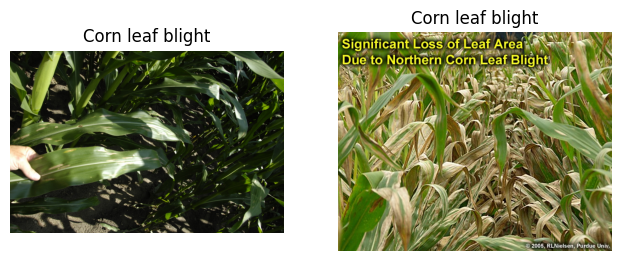

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

plant_name = "Corn"

# find classes containing that plant
plant_classes = [c for c in os.listdir(base_dir) if plant_name.lower() in c.lower()]

plt.figure(figsize=(12,12))

for i in range(2):

    sample_class = random.choice(plant_classes)
    sample_image = random.choice(os.listdir(os.path.join(base_dir, sample_class)))

    img_path = os.path.join(base_dir, sample_class, sample_image)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(sample_class)
    plt.axis("off")

plt.show()

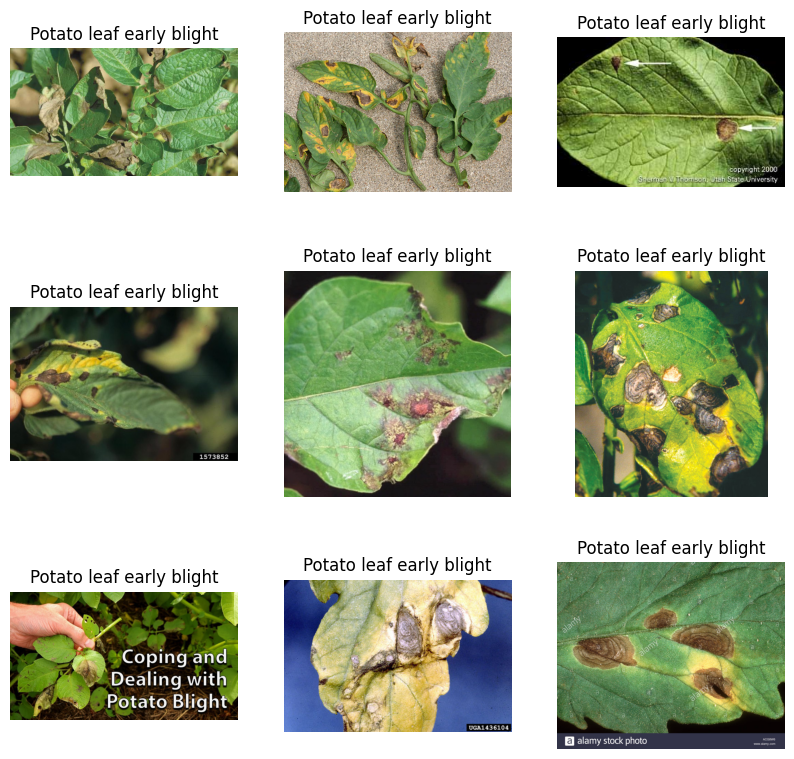

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

class_name = "Potato leaf early blight"

folder_path = os.path.join(base_dir, class_name)

images = os.listdir(folder_path)

plt.figure(figsize=(10,10))

for i in range(9):   # show 9 images

    img_path = os.path.join(folder_path, images[i])

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

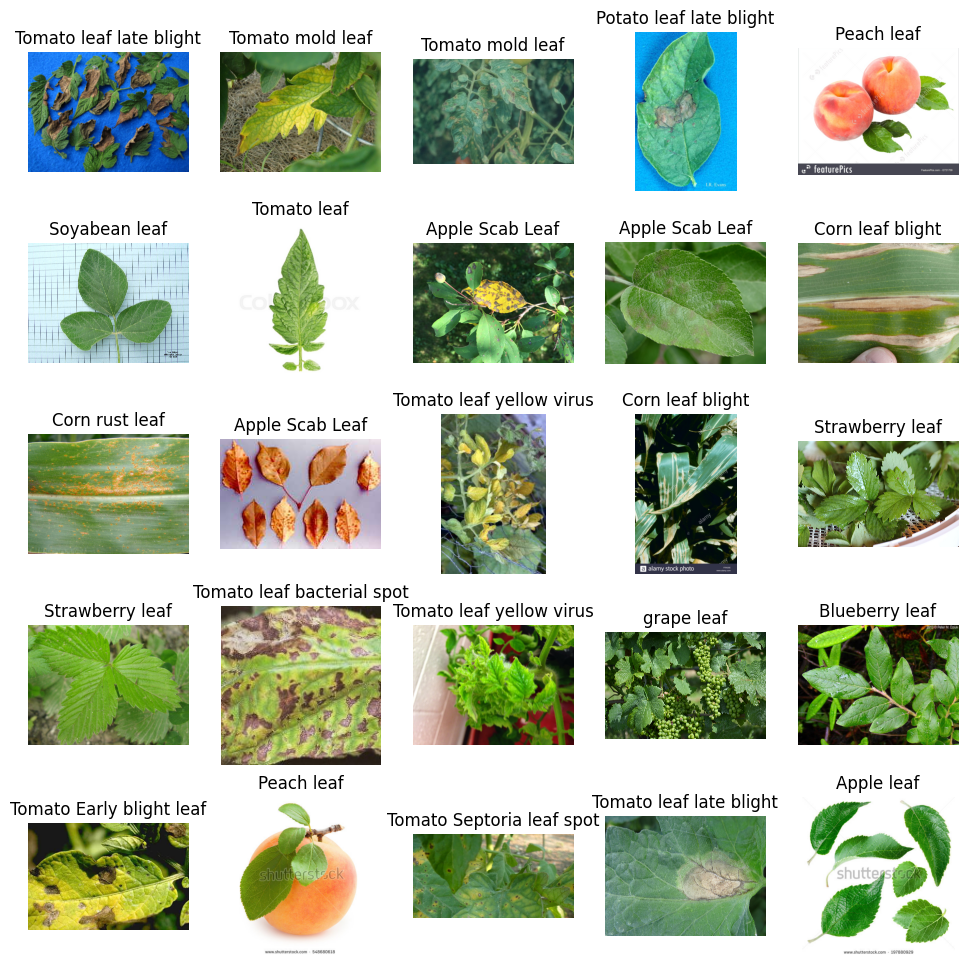

In [ ]:
import matplotlib.pyplot as plt
import random
import os
import cv2

plt.figure(figsize=(12,12))

num_images = 25   # number of images you want

for i in range(num_images):

    sample_class = random.choice(os.listdir(base_dir))
    sample_image = random.choice(os.listdir(os.path.join(base_dir, sample_class)))

    img_path = os.path.join(base_dir, sample_class, sample_image)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(5,5,i+1)
    plt.imshow(img)
    plt.title(sample_class)
    plt.axis("off")

plt.show()

In [ ]:
# IMAGE PREPROCESSING

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 64
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1866 images belonging to 27 classes.
Found 450 images belonging to 27 classes.


In [ ]:
import numpy as np

X_batch, y_batch = next(train_data)

# flatten images
features = X_batch.reshape(X_batch.shape[0], -1)

# reduce features for quantum circuit
features = features[:, :4]

print(features.shape)

(32, 4)


In [ ]:
!pip install qiskit qiskit-machine-learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00


In [ ]:
!pip install pylatexenc

In [ ]:
import os
os.kill(os.getpid(), 9)

/tmp/ipykernel_10748/702019356.py:3: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=4, reps=2)


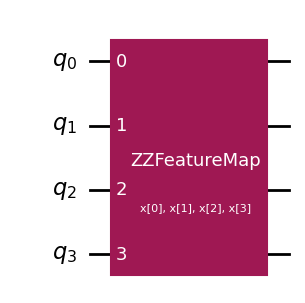

In [ ]:
from qiskit.circuit.library import ZZFeatureMap

feature_map = ZZFeatureMap(feature_dimension=4, reps=2)

feature_map.draw('mpl')

/tmp/ipykernel_10748/2201419969.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(


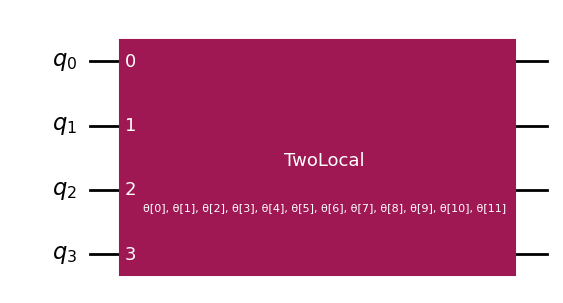

In [ ]:
from qiskit.circuit.library import TwoLocal

ansatz = TwoLocal(
    num_qubits=4,
    rotation_blocks='ry',
    entanglement_blocks='cz',
    reps=2
)

ansatz.draw('mpl')

In [ ]:
!pip install qiskit-algorithms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 5.7 MB/s eta 0:00:00


In [ ]:
import os
os.kill(os.getpid(),9)

In [ ]:
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA

vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=COBYLA(maxiter=100)
)

In [ ]:
import numpy as np

features = np.random.rand(50,4)   # 50 samples, 4 features
y_batch = np.random.randint(0,2,(50,2))

In [ ]:
X_train = features
y_train = np.argmax(y_batch, axis=1)

vqc.fit(X_train, y_train)

In [ ]:
predictions = vqc.predict(X_train)

print(predictions[:10])

[0 0 1 1 0 1 0 1 0 0]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_train, predictions)

print("Quantum Model Accuracy:", accuracy)

Quantum Model Accuracy: 0.84
